### Лабораторная работа №2

In [8]:
import numpy as np

class NeuralNetwork:
    weight: np.ndarray
    bias: np.ndarray
    
    def __init__(self, n_neurons: int, n_inputs: int):
        self.weight = np.random.uniform(0.001, 0.2, (n_neurons, n_inputs))
        self.bias = np.zeros(n_neurons)
    
    def _activation_function(self, x: np.ndarray) -> np.ndarray:
        return x
    
    def predict(self, x: np.ndarray) -> np.ndarray:
        if len(x.shape) == 1:
            x = x.reshape(-1, 1)
        weighted_sum = np.dot(self.weight, x) + self.bias.reshape(-1, 1)
        return self._activation_function(weighted_sum).flatten()
    
    def fit_1(self, x: np.ndarray, y: np.ndarray):
        for k in range(len(x)):
            x_k = x[k]
            y_k = y[k]
            y_pred = self.predict(x_k)
            
            for i in range(len(self.weight)):
                sum_x = np.sum(x_k)
                if abs(sum_x) > 1e-10:
                    delta = (y_k[i] - y_pred[i]) / sum_x
                    self.weight[i] += delta
    
    def fit_2(self, x: np.ndarray, y: np.ndarray, alpha: float):
        for k in range(len(x)):
            x_k = x[k].reshape(-1, 1)
            y_k = y[k].reshape(-1, 1)
            y_pred = self.predict(x_k).reshape(-1, 1)
            error = y_pred - y_k
            delta = alpha * np.dot(error, x_k.T)
            self.weight -= delta
    
    def fit(self, x: np.ndarray, y: np.ndarray, alpha: float = 0.01, target_error: float = 0.001, max_epochs: int = 1000):
        epoch = 0
        
        while epoch < max_epochs:
            total_error = 0
            
            for k in range(len(x)):
                x_k = x[k].reshape(-1, 1)
                y_k = y[k].reshape(-1, 1)
                y_pred = self.predict(x_k).reshape(-1, 1)
                error = y_pred - y_k
                delta = alpha * np.dot(error, x_k.T)
                self.weight -= delta
                
                total_error += np.sum(0.5 * (error ** 2))
            
            mse = total_error / len(x)
            
            if mse < target_error:
                break
                
            epoch += 1

In [9]:
from PIL import Image
import matplotlib.pyplot as plt

def read_data(file: str, has_target: bool = True):
    x_data = []
    y_data = []
    
    with open(file, "r") as data:
        next(data)
        
        for line in data:
            line = line.strip()
            if line:
                values = line.split(",")
                try:
                    float_values = list(map(float, values))
                    if has_target:
                        if len(float_values) == 3:
                            x_data.append(float_values[:2])
                            y_data.append([float_values[2]])
                        elif len(float_values) == 9:
                            x_data.append(float_values[:6])
                            y_data.append(float_values[6:])
                        else:
                            x_data.append(float_values[:-1])
                            y_data.append([float_values[-1]])
                    else:
                        x_data.append(float_values)
                except ValueError:
                    continue
    
    x_data = np.array(x_data, dtype=np.float32)
    y_data = np.array(y_data, dtype=np.float32) if has_target else None
    
    return x_data, y_data

def read_rgb_data(file: str, skip_header: bool = True):
    x_data = []
    y_data = []
    
    with open(file, "r") as data:
        if skip_header:
            next(data)
        
        for line in data:
            line = line.strip()
            if line:
                values = line.split(",")
                try:
                    if len(values) >= 4:
                        x_data.append([float(values[0]), float(values[1]), float(values[2])])
                        y_data.append([float(values[3])])
                except ValueError:
                    continue
    
    x_data = np.array(x_data, dtype=np.float32)
    y_data = np.array(y_data, dtype=np.float32)
    
    return x_data, y_data


def split_data(x: np.ndarray, y: np.ndarray, train_ratio: float = 0.8, seed: int = 42):
    if len(x) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])
    
    n = len(x)
    train_size = int(n * train_ratio)
    
    np.random.seed(seed)
    indices = np.random.permutation(n)
    train_idx = indices[:train_size]
    test_idx = indices[train_size:]
    
    x_train = x[train_idx]
    y_train = y[train_idx]
    x_test = x[test_idx]
    y_test = y[test_idx]
    
    return x_train, y_train, x_test, y_test

def process_image_for_red_detection(network, image_path: str):
    img = Image.open(image_path)
    img_array = np.asarray(img)
    height, width, channels = img_array.shape
    
    print(f"Размер изображения: {width}x{height}, Каналы: {channels}")
    
    mas = img_array.reshape(height * width, channels)
    red_mask = np.zeros(height * width, dtype=np.float32)
    
    for i in range(len(mas)):
        pixel = mas[i] / 255.0
        prediction = network.predict(pixel)
        red_mask[i] = prediction[0]
    
    red_mask_normalized = np.clip(red_mask * 100, 0, 100)
    red_mask_reshaped = red_mask_normalized.reshape(height, width)
       
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    
    axes[0].imshow(img_array)
    axes[0].set_title('Оригинальное изображение')
    axes[0].axis('off')
    
    im = axes[1].imshow(red_mask_reshaped, cmap='Reds', vmin=0, vmax=100)
    axes[1].set_title('Обнаружение красного цвета')
    axes[1].axis('off')
    
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    plt.suptitle('Распознавание красного цвета на изображении', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    red_mask_uint8 = np.clip(red_mask_reshaped * 2.55, 0, 255).astype(np.uint8)
    mask_img = Image.fromarray(red_mask_uint8, mode="L")
    mask_img.save("red_mask_result.jpg")
    
    return red_mask_reshaped

In [12]:
print("=== Задание 1 ===")
x_data, y_data = read_data("data/2lab.csv")
x_train, y_train, x_test, y_test = split_data(x_data, y_data, 0.8)
nn1 = NeuralNetwork(n_neurons=1, n_inputs=2)
nn2 = NeuralNetwork(n_neurons=1, n_inputs=2)

for _ in range(50):
    nn1.fit_1(x_train, y_train)
    nn2.fit_2(x_train, y_train, alpha=0.0001)

print(f"Сеть 1 (метод 1): Веса = {nn1.weight[0]}")
print(f"Сеть 2 (метод 2): Веса = {nn2.weight[0]}")

=== Задание 1 ===
Сеть 1 (метод 1): Веса = [2.5533506  2.40268698]
Сеть 2 (метод 2): Веса = [ 3. -2.]


In [10]:
print("\n=== Задание 2 ===")
x_data_2, y_data_2 = read_data("data/2lab_data.csv")

x_train_2, y_train_2, x_test_2, y_test_2 = split_data(x_data_2, y_data_2, 0.8)
nn3 = NeuralNetwork(n_neurons=3, n_inputs=6)
nn3.fit(x_train_2, y_train_2, alpha=0.000001, target_error=1000.0)

print("\nПроверка предсказаний (первые 3 примера):")
for i in range(min(3, len(x_test_2))):
    prediction = nn3.predict(x_test_2[i])
    actual = y_test_2[i]
    print(f"Пример {i+1}: Предсказание={prediction}, Фактическое={actual}")


=== Задание 2 ===

Проверка предсказаний (первые 3 примера):
Пример 1: Предсказание=[781.42856386 265.13169916 106.61141333], Фактическое=[788. 258. 101.]
Пример 2: Предсказание=[976.04698065 284.16360918 272.66160048], Фактическое=[1000.  276.  252.]
Пример 3: Предсказание=[539.62355857 240.98442964 -96.56389442], Фактическое=[508. 221. -82.]



=== Задание 3 ===
Размер изображения: 1920x1080, Каналы: 3


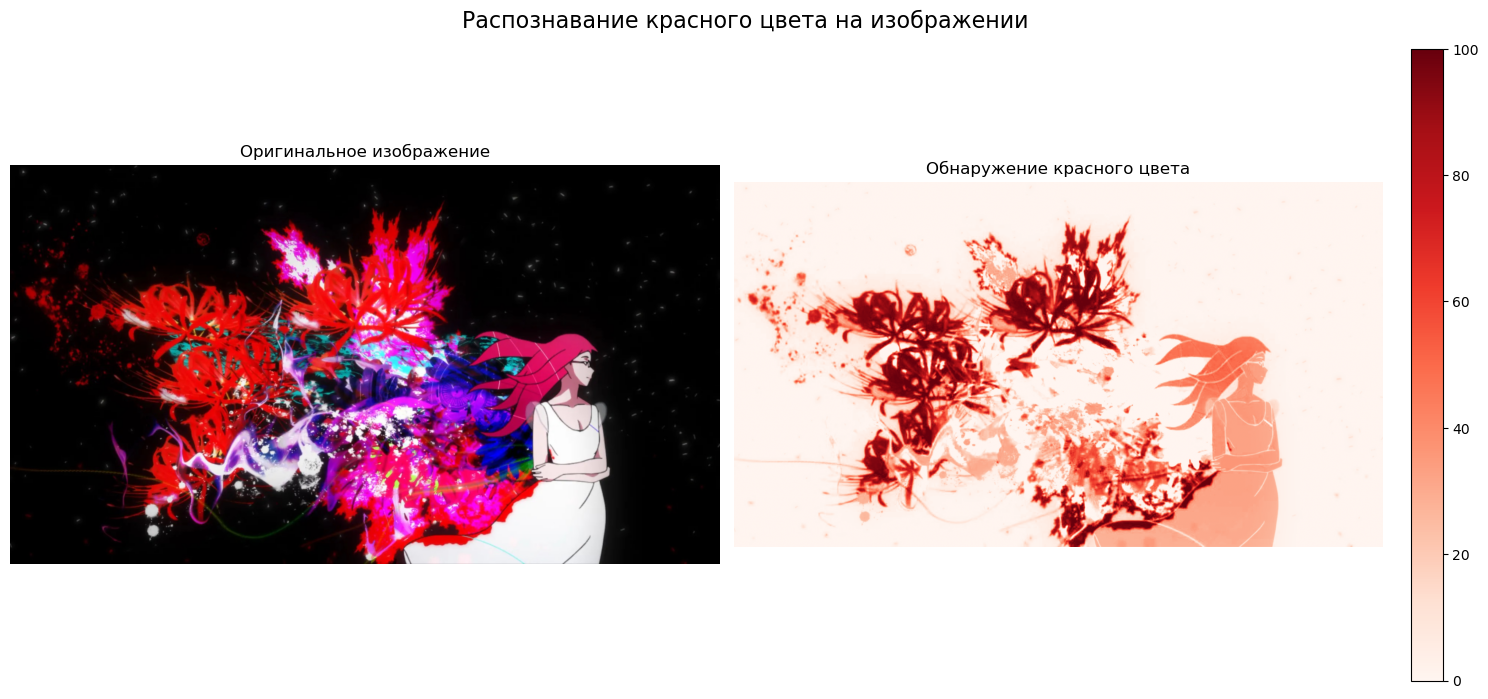

In [11]:
print("\n=== Задание 3 ===")
x_train_rgb, y_train_rgb = read_rgb_data("data/2lab_data_3_train.csv")
x_test_rgb, y_test_rgb = read_rgb_data("data/2lab_data_3_test.csv")
        
nn_rgb = NeuralNetwork(n_neurons=1, n_inputs=3)

x_train_norm = x_train_rgb / 255.0
y_train_norm = y_train_rgb.copy()

nn_rgb.fit(x_train_norm, y_train_norm, alpha=0.1, target_error=0.05)
        
result = process_image_for_red_detection(nn_rgb, "data/pic.jpg")